In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

print("1. Загрузка данных")
df = pd.read_csv("employeeDataset.csv")
print(df.head())
# Информация о датасете
print("\n2. Общая информация о датасете:")
df.info()
print('\nИнформация о столбцах')
numeric_columns = df.select_dtypes(include='number').columns
categorical_columns = df.select_dtypes(exclude='number').columns

print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

1. Загрузка данных
   Education  JoiningYear       City  PaymentTier  Age  Gender EverBenched  \
0  Bachelors         2017  Bangalore            3   34    Male          No   
1  Bachelors         2013       Pune            1   28  Female          No   
2  Bachelors         2014  New Delhi            3   38  Female          No   
3    Masters         2016  Bangalore            3   27    Male          No   
4    Masters         2017       Pune            3   24    Male         Yes   

   ExperienceInCurrentDomain  LeaveOrNot  
0                          0           0  
1                          3           1  
2                          2           0  
3                          5           1  
4                          2           1  

2. Общая информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Education    

In [4]:
# Проверка целевой переменной
print("\nРаспределение целевой переменной:")
print(df['LeaveOrNot'].value_counts())
print(df['LeaveOrNot'].value_counts(normalize=True).map(lambda x: f"{x:.2%}"))


Распределение целевой переменной:
LeaveOrNot
0    3053
1    1600
Name: count, dtype: int64
LeaveOrNot
0    65.61%
1    34.39%
Name: proportion, dtype: str


In [17]:
# Статистика по числовым столбцам
print("\nСтатистика по числовым признакам:")
print(df.describe())


Статистика по числовым признакам:
       JoiningYear  PaymentTier          Age  ExperienceInCurrentDomain  \
count  4653.000000  4653.000000  4653.000000                4653.000000   
mean   2015.062970     2.698259    29.393295                   2.905652   
std       1.863377     0.561435     4.826087                   1.558240   
min    2012.000000     1.000000    22.000000                   0.000000   
25%    2013.000000     3.000000    26.000000                   2.000000   
50%    2015.000000     3.000000    28.000000                   3.000000   
75%    2017.000000     3.000000    32.000000                   4.000000   
max    2018.000000     3.000000    41.000000                   7.000000   

        LeaveOrNot  
count  4653.000000  
mean      0.343864  
std       0.475047  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%       1.000000  
max       1.000000  


In [ ]:
print("\n3. Обработка пропущенных значений")

print('Проверка пропусков:')
print(df.isnull().sum())

print("\nКоличество пропущенных значений по столбцам:")
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'missing_values': missing_values,
                          'percent_missing': missing_percent.round(2)})
print(missing_df[missing_df['missing_values'] > 0])
if missing_df['missing_values'].sum() > 0:
    # Числовые признаки заполняем медианой
    numeric_cols = df.select_dtypes(include=['number']).columns
    for col in numeric_cols:
        if df[col].isnull().sum() > 0:
            median_value = df[col].median()
            df[col].fillna(median_value, inplace=True)
            print(f"Заполнили пропуски в столбце {col} медианным значением: {median_value}")

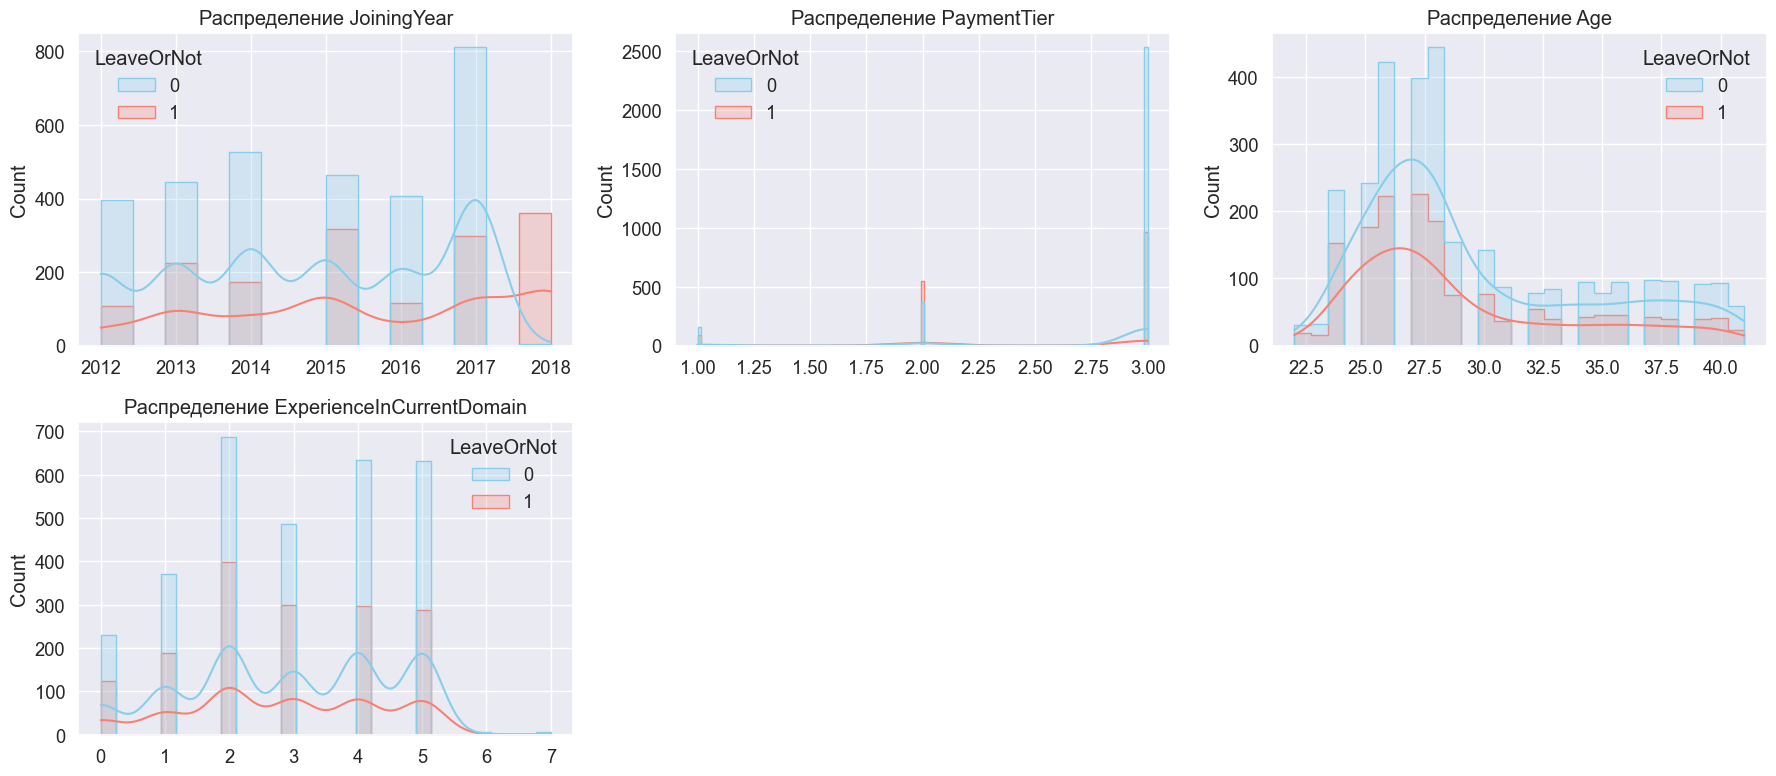

In [5]:
exclude_from_plots = ['LeaveOrNot']
cols_to_plot = [c for c in numeric_columns if c not in exclude_from_plots]

def plot_distributions(dataframe, features_list, target_column, n_cols=3):
    n_rows = int(np.ceil(len(features_list) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
    axes = axes.flatten()

    for i, feature in enumerate(features_list):
        ax = axes[i]
        try:
            sns.histplot(data=dataframe, x=feature, hue=target_column,
                         kde=True, element="step", ax=ax, palette=['skyblue', 'salmon'])
            ax.set_title(f'Распределение {feature}')
        except:
            sns.histplot(data=dataframe, x=feature, hue=target_column,
                         element="step", ax=ax, palette=['skyblue', 'salmon'])
            ax.set_title(f'Распределение {feature} (KDE skipped)')
        ax.set_xlabel('')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_distributions(df, cols_to_plot, target_column='LeaveOrNot')

In [14]:
print("\nРешение задачи регрессии - предсказание опыта")

# Разделяем данные до кодирования
X = df.drop(['ExperienceInCurrentDomain'], axis=1)
y = df['ExperienceInCurrentDomain']

X_temp, X_test_r, y_temp, y_test_r = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

# Кодирование категориальных признаков
X_train_r = pd.get_dummies(X_train_r, drop_first=True)
X_val_r = pd.get_dummies(X_val_r, drop_first=True)
X_test_r = pd.get_dummies(X_test_r, drop_first=True)

X_train_r, X_val_r = X_train_r.align(X_val_r, join='left', axis=1, fill_value=0)
X_train_r, X_test_r = X_train_r.align(X_test_r, join='left', axis=1, fill_value=0)

# Масштабирование
scaler_r = StandardScaler()
X_train_scaled = scaler_r.fit_transform(X_train_r)
X_val_scaled = scaler_r.transform(X_val_r)
X_test_scaled = scaler_r.transform(X_test_r)

lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train_r)
y_pred_lin = lin_model.predict(X_test_scaled)

print("\nЛинейная регрессия")
print(f"MAE: {mean_absolute_error(y_test_r, y_pred_lin):.2f}")
print(f"RMSE: {root_mean_squared_error(y_test_r, y_pred_lin):.2f}")
print(f"R2: {r2_score(y_test_r, y_pred_lin):.2f}")

# Полиномиальная + Ridge
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

reg_model = Ridge(alpha=1.0)
reg_model.fit(X_train_poly, y_train_r)
y_pred_reg = reg_model.predict(X_test_poly)

print("\nПолиномиальная регрессия + Ridge")
print(f"MAE: {mean_absolute_error(y_test_r, y_pred_reg):.2f}")
print(f"RMSE: {root_mean_squared_error(y_test_r, y_pred_reg):.2f}")
print(f"R2 Score: {r2_score(y_test_r, y_pred_reg):.2f}")



Решение задачи регрессии (предсказание опыта)

Линейная регрессия
MAE: 1.32
RMSE: 1.54
R2: 0.01

Полиномиальная регрессия + Ridge
MAE: 1.31
RMSE: 1.53
R2 Score: 0.02



LeaveOrNot
Accuracy: 0.747134670487106

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.89      0.82       916
           1       0.70      0.47      0.56       480

    accuracy                           0.75      1396
   macro avg       0.73      0.68      0.69      1396
weighted avg       0.74      0.75      0.73      1396



C:\Users\Софи\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


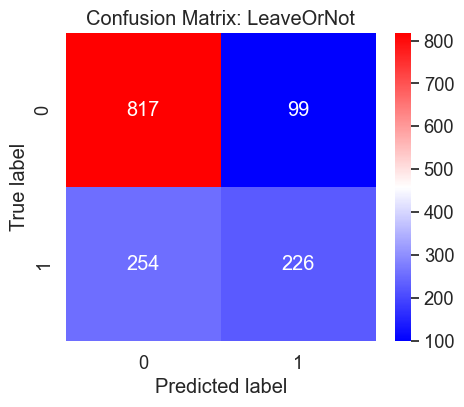

In [19]:
print("\nLeaveOrNot")
# Разделение данных до кодирования
X = df.drop('LeaveOrNot', axis=1)
y = df['LeaveOrNot']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
# Кодирование категориальных признаков
X_train_c = pd.get_dummies(X_train_c, drop_first=True)
X_test_c = pd.get_dummies(X_test_c, drop_first=True)

# Выровнять колонки
X_train_c, X_test_c = X_train_c.align(X_test_c, join='left', axis=1, fill_value=0)
# Масштабирование
scaler_c = MinMaxScaler()
X_train_scaled = scaler_c.fit_transform(X_train_c)
X_test_scaled = scaler_c.transform(X_test_c)

# Логистическая регрессия
logreg_model = LogisticRegression(max_iter=5000, penalty='l2', random_state=42)
logreg_model.fit(X_train_scaled, y_train_c)
y_pred_class = logreg_model.predict(X_test_scaled)
# Оценка
print("Accuracy:", accuracy_score(y_test_c, y_pred_class))
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_class))

# Матрица ошибок 
cm = confusion_matrix(y_test_c, y_pred_class)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='bwr')
plt.title('Confusion Matrix: LeaveOrNot')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


с балансировкой весов
Accuracy (может немного упасть): 0.6840974212034384

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.72      0.75       916
           1       0.53      0.62      0.58       480

    accuracy                           0.68      1396
   macro avg       0.66      0.67      0.66      1396
weighted avg       0.70      0.68      0.69      1396



C:\Users\Софи\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


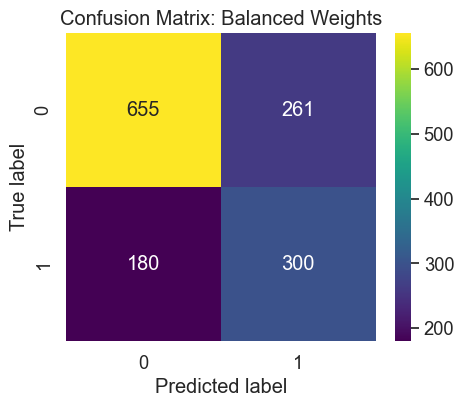

In [16]:
# Улучшенная классификация
print("\nс балансировкой весов")

# Инициализируем модель с весами классов
logreg_balanced = LogisticRegression(max_iter=5000, class_weight='balanced', penalty='l2')
logreg_balanced.fit(X_train_c, y_train_c)
y_pred_balanced = logreg_balanced.predict(X_test_c)

# Новые метрики
print("Accuracy (может немного упасть):", accuracy_score(y_test_c, y_pred_balanced))
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_balanced))

# новая матрица ошибок
cm_balanced = confusion_matrix(y_test_c, y_pred_balanced)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='viridis') # Поменял цвет для наглядности
plt.title('Confusion Matrix: Balanced Weights')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [11]:
print("\nАнализ регрессии:")
if r2_score(y_test_r, y_pred_reg) > 0.7:
    print("Модель хорошо объясняет данные")
elif r2_score(y_test_r, y_pred_reg) > 0.4:
    print("Среднее качество модели")
else:
    print("Модель работает плохо, необхдимо улучшение")

    from sklearn.metrics import precision_score, recall_score, f1_score
print("Precision:", precision_score(y_test_c, y_pred_class))
print("Recall:", recall_score(y_test_c, y_pred_class))
print("F1-score:", f1_score(y_test_c, y_pred_class))


Анализ качества регрессии:
Модель работает плохо, требуется улучшение
Precision: 0.7043189368770764
Recall: 0.44537815126050423
F1-score: 0.5456885456885456


In [20]:
print("\nАнализ качества классификации")

#Дисбаланс классов
class_counts = y_train_c.value_counts(normalize=True)
print("\nРаспределение классов (train):")
print(class_counts)

if class_counts.min() < 0.4:
    print("Наблюдается дисбаланс классов")
else:
    print("Дисбаланс классов незначительный")

precision = precision_score(y_test_c, y_pred_class)
recall = recall_score(y_test_c, y_pred_class)
f1 = f1_score(y_test_c, y_pred_class)
acc = accuracy_score(y_test_c, y_pred_class)

print("\nБез балансировки")
print(f"Accuracy: {acc:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

precision_bal = precision_score(y_test_c, y_pred_balanced)
recall_bal = recall_score(y_test_c, y_pred_balanced)
f1_bal = f1_score(y_test_c, y_pred_balanced)
acc_bal = accuracy_score(y_test_c, y_pred_balanced)

print("\nС балансировкой")
print(f"Accuracy: {acc_bal:.2f}")
print(f"Precision: {precision_bal:.2f}")
print(f"Recall: {recall_bal:.2f}")
print(f"F1-score: {f1_bal:.2f}")

print("\nСравнение моделей")
if recall_bal > recall:
    print("Улучшилась полнота Recall = модель лучше находит увольнения")
if precision_bal < precision:
    print("Точность Precision снизилась = больше ложных срабатываний")
if f1_bal > f1:
    print("Общий баланс модели F1-score улучшился")
if acc_bal < acc:
    print("Accuracy снизилась")

#Анализ ошибок
tn, fp, fn, tp = confusion_matrix(y_test_c, y_pred_balanced).ravel()

print("\nАнализ ошибок")
print(f"False Positive (предсказали уход, но не ушёл): {fp}")
print(f"False Negative (не предсказали уход, но ушёл): {fn}")

if fn > fp:
    print("Модель чаще пропускает увольнения (FN). Это критично для задачи")
else:
    print("Модель чаще ошибочно предсказывает увольнение (FP)")

print("В данной задаче важнее минимизировать FN, чтобы не пропускать сотрудников, которые могут уволиться.")


Анализ качества классификации

Распределение классов (train):
LeaveOrNot
0    0.656125
1    0.343875
Name: proportion, dtype: float64
Наблюдается дисбаланс классов

Без балансировки
Accuracy: 0.75
Precision: 0.70
Recall: 0.47
F1-score: 0.56

С балансировкой
Accuracy: 0.68
Precision: 0.53
Recall: 0.62
F1-score: 0.58

Сравнение моделей
Улучшилась полнота Recall = модель лучше находит увольнения
Точность Precision снизилась = больше ложных срабатываний
Общий баланс модели F1-score улучшился
Accuracy снизилась

Анализ ошибок
False Positive (предсказали уход, но не ушёл): 261
False Negative (не предсказали уход, но ушёл): 180
Модель чаще ошибочно предсказывает увольнение (FP)

Вывод:
В данной задаче важнее минимизировать FN, чтобы не пропускать сотрудников, которые могут уволиться.
